Step 1: Modify the Neural Network

To add an additional hidden layer with 16 neurons and the ReLU activation function, you'll modify the architecture of the original feedforward network.

In [3]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode the target labels
y_one_hot = tf.keras.utils.to_categorical(y, num_classes=3)

# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Build the original neural network (before modification)
original_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer with softmax
])

original_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the original model
original_history = original_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

# Evaluate the original model
original_test_loss, original_test_accuracy = original_model.evaluate(X_test, y_test)

# Modify the model by adding an additional hidden layer with 16 neurons
modified_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),  # Additional hidden layer
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer with softmax
])

modified_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the modified model
modified_history = modified_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

# Evaluate the modified model
modified_test_loss, modified_test_accuracy = modified_model.evaluate(X_test, y_test)

# Compare results
print(f"Original model test accuracy: {original_test_accuracy:.4f}")
print(f"Modified model test accuracy: {modified_test_accuracy:.4f}")

# You can also compare training loss and accuracy over epochs for both models.


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.3464 - loss: 1.8119 - val_accuracy: 0.5238 - val_loss: 1.4388
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3073 - loss: 1.8519 - val_accuracy: 0.5238 - val_loss: 1.4217
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2956 - loss: 1.8484 - val_accuracy: 0.5238 - val_loss: 1.4045
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2917 - loss: 1.9041 - val_accuracy: 0.5238 - val_loss: 1.3879
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3307 - loss: 1.7878 - val_accuracy: 0.5238 - val_loss: 1.3719
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3034 - loss: 1.7669 - val_accuracy: 0.5714 - val_loss: 1.3559
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3307 - loss: 1.7378 - val_accuracy: 0.5714 - val_loss: 1.3403
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3151 - loss: 1.6817 - val_accuracy: 0.5714 - val_loss: 1.3249
Epoch 9/50

KeyboardInterrupt: 

Load and preprocess the Wine dataset by scaling the features and one-hot encoding the target labels.

In [5]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target.reshape(-1, 1)  # Ensure y is a column vector

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode the target labels
encoder = OneHotEncoder(sparse_output=False)  # Corrected argument name
y_one_hot = encoder.fit_transform(y)

# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Check the resulting shapes
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)



Shape of X_train: (99, 13)
Shape of y_train: (99, 3)
Shape of X_test: (54, 13)
Shape of y_test: (54, 3)


Build a neural network with two hidden layers, 8 neurons in the first hidden layer and 16 in the second, using ReLU activation for all layers except the output layer.

In [6]:
# Build the Wine classification model
wine_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),  # Second hidden layer
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer with softmax
])

wine_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
wine_history = wine_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

# Evaluate the model
wine_test_loss, wine_test_accuracy = wine_model.evaluate(X_test, y_test)

print(f"Wine dataset test accuracy: {wine_test_accuracy:.4f}")


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.2859 - loss: 1.2419 - val_accuracy: 0.4000 - val_loss: 1.1521
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3397 - loss: 1.1305 - val_accuracy: 0.4000 - val_loss: 1.1262
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2939 - loss: 1.1730 - val_accuracy: 0.4400 - val_loss: 1.1011
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4138 - loss: 1.1282 - val_accuracy: 0.4400 - val_loss: 1.0766
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4788 - loss: 1.0635 - val_accuracy: 0.4000 - val_loss: 1.0553
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4616 - loss: 1.0709 - val_accuracy: 0.4000 - val_loss: 1.0352
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5110 - loss: 1.0345 - val_accuracy: 0.4800 - val_loss: 1.0156
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5961 - loss: 0.9702 - val_accuracy: 0.5600 - val_loss: 0.9977
Epoch 9/50


KeyboardInterrupt: 

Additionally, visualize the confusion matrix for the test predictions:

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


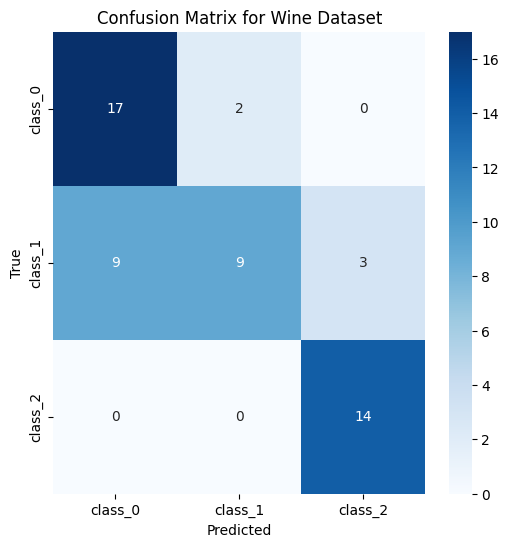

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt  # Importing plt from matplotlib

# Predict on the test set
y_pred = wine_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Wine Dataset')
plt.show()

